## **EE5841 Final Project**

Members: Jackson Newell, Jayden Cozort, Reid Beckes, Md Istiak Ahammed

##### **Current Notes:**
Using the MNIST dataset to test the ResNet implementation

Using population data for Apidae (Family of bees including honey bees, bumble bees, etc.)
- Whole world dataset is +8,000,000 occurances. Too big for testing. Going to use just the US which is +2,000,000, may be more managable.
Changes currently to make:
- Import SDM (Occurance) data from GBIF (Jackson currently has the Apidae occurance dataset downloaded)
- Create dataset to train and test with
  - Get Lat a Long for the input
  - Create corresponding matrix of ouputs [0, 1]

##### **Sources:**

GBIF.org (22 March 2026) GBIF Occurrence Download  https://doi.org/10.15468/dl.ggr73u

[GeeksforGeeks ResNet Implementation, used code from here for project](https://www.geeksforgeeks.org/deep-learning/residual-networks-resnet-deep-learning/)

[GeeksforGeeks UNet Implementation, used code from here for the project](https://www.geeksforgeeks.org/machine-learning/u-net-architecture-explained/)

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Conv2D, Convolution2DTranspose
from tensorflow.keras.layers import AveragePooling2D, Input, Flatten, Add, MaxPool2D, Resizing, Concatenate
from tensorflow.keras.utils import split_dataset
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
from keras.datasets import mnist
from google.colab import files
import matplotlib.pyplot as plt
import random
import rasterio
import cv2
from google.colab.patches import cv2_imshow
import math

device_name = tf.test.gpu_device_name()
if not device_name:
    raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

print("TensorFlow:", tf.__version__)

Found GPU at: /device:GPU:0
TensorFlow: 2.19.0


In [4]:
num_data = 500

# (x_train, y_train), (x_test, y_test) = mnist.load_data()

# x_train = x_train.astype('float32') / 255
# x_test = x_test.astype('float32') / 255

# x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
# x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

# input_shape = x_train.shape[1:]

# print(input_shape)

# y_train = keras.utils.to_categorical(y_train, num_class)
# y_test = keras.utils.to_categorical(y_test, num_class)

def data_generate():
  file_forest = rasterio.open('/content/drive/Shareddrives/EE5841 Final Project/distance_to_forest.tif')
  size = file_forest.block_shapes[0][0]
  y_max = math.ceil(file_forest.shape[0] / size)
  x_max = math.ceil(file_forest.shape[1] / size)
  forest_test_y = random.randint(round(y_max/3), round(y_max * 2 / 3))
  forest_test_x = random.randint(round(x_max/3), round(x_max * 2 / 3))

  window_forest = file_forest.block_window(1, forest_test_y, forest_test_x)
  data_forest = file_forest.read(window=window_forest)
  data_forest = np.reshape(data_forest, (256, 256, 1))
  # cv2_imshow(data_forest)


  file_water = rasterio.open('/content/drive/Shareddrives/EE5841 Final Project/distance_to_water.tif')
  size = file_water.block_shapes[0][0]
  y_max = math.ceil(file_water.shape[0] / size)
  x_max = math.ceil(file_water.shape[1] / size)
  water_test_y = forest_test_y
  water_test_x = forest_test_x

  window_water = file_water.block_window(1, water_test_y, water_test_x)
  data_water = file_water.read(window=window_water)
  data_water = np.reshape(data_water, (256, 256, 1))
  # print("Data Shape: ", data_water.shape)
  # print("Block: ", water_test_y, water_test_x)
  # cv2_imshow(data_water)

  zeros = np.zeros((256, 256, 1)) # Zeros for visualization purposes

  data_combined = np.concatenate((data_forest, data_water), axis = 2)
  data_combined = ((data_combined - np.min(data_combined)) / (np.max(data_combined) - np.min(data_combined) + 1e-6))

  data_visual = np.concatenate((data_combined, zeros), axis = 2)
  # cv2_imshow(data_visual) # Doesn't tell us much, but confirms the concatination

  file_label = rasterio.open('/content/drive/Shareddrives/EE5841 Final Project/Feature_c0071.tif')
  label_y = water_test_y * 2
  label_x = water_test_x * 2

  window_label = file_label.block_window(1, label_y, label_x)
  data_label1 = file_label.read(window=window_label)
  #print("label 1: ", data_label1)

  window_label = file_label.block_window(1, label_y+1, label_x)
  data_label2 = np.concatenate((data_label1, file_label.read(window=window_label)), axis = 2)
  #print("label 2: ", data_label2)

  window_label = file_label.block_window(1, label_y, label_x+1)
  data_label3 = file_label.read(window=window_label)
  #print("label 3: ", data_label3)

  window_label = file_label.block_window(1, label_y+1, label_x+1)
  data_label4 = np.concatenate((data_label3, file_label.read(window=window_label)), axis = 2)
  #print("label 4: ", data_label4)

  data_label = np.concatenate((data_label2, data_label4), axis=1)

  data_label = np.reshape(data_label, (data_label.shape[1], data_label.shape[2], 1))
  data_label = ((data_label - np.min(data_label)) / (np.max(data_label) - np.min(data_label) + 1e-6))

  return data_label, data_combined

dataset_out = []
dataset_in = []
for i in range(num_data):
  output, input = data_generate()
  dataset_out.append(output)
  dataset_in.append(input)

dataset_out = np.reshape(dataset_out, (num_data, 256, 256, 1))
dataset_in = np.reshape(dataset_in, (num_data, 256, 256, 2))
print(np.shape(dataset_out), np.shape(dataset_in))


(500, 256, 256, 1) (500, 256, 256, 2)


### U NET MODEL

In [5]:
def encoder(input, num_filters):
  x = Conv2D(num_filters, 3, padding='same')(input)
  x = Activation('relu')(x)

  x = Conv2D(num_filters, 3, padding='same')(x)
  x = Activation('relu')(x)

  x = MaxPool2D(pool_size=(2,2), strides=2)(x)

  return x

def decoder(input, skip, num_filters):
  x = Convolution2DTranspose(num_filters, (2,2), strides=2, padding='same')(input)

  skip = Resizing(x.shape[1], x.shape[2])(skip)
  x = Concatenate()([x, skip])
  x = Conv2D(num_filters, 3, padding='same')(x)
  x = Activation('relu')(x)
  x = Conv2D(num_filters, 3, padding='same')(x)
  x = Activation('relu')(x)

  return x

def unet_model(input_shape=(28, 28, 1), num_classes=1):
  inputs = Input(shape=input_shape, name='image')

  encoder_block1 = encoder(inputs, 64)
  encoder_block2 = encoder(encoder_block1, 128)
  encoder_block3 = encoder(encoder_block2, 256)
  encoder_block4 = encoder(encoder_block3, 512)

  bottleneck = Conv2D(1024, 3, padding='same')(encoder_block4)
  bottleneck = Activation('relu')(bottleneck)
  bottleneck = Conv2D(1024, 3, padding='same')(bottleneck)
  bottleneck = Activation('relu')(bottleneck)

  decoder_block1 = decoder(bottleneck, encoder_block4, 512)
  decoder_block2 = decoder(decoder_block1, encoder_block3, 256)
  decoder_block3 = decoder(decoder_block2, encoder_block2, 128)
  decoder_block4 = decoder(decoder_block3, encoder_block1, 64)

  outputs = Conv2D(num_classes, (1, 1), activation='sigmoid')(decoder_block4)

  model = Model(inputs=inputs, outputs=outputs, name='UNET')
  return model

In [6]:
import tensorflow_datasets as tfds


model2 = unet_model(input_shape=(256, 256, 2), num_classes=1)
model2.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=1e-5),
              metrics=['accuracy'])
model2.summary()

Model: "UNET"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,216 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ activation_4[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[

 Total params: 31,031,169 (118.37 MB)

 Trainable params: 31,031,169 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
epochs = 10
batch_size = 32

hist = model2.fit(dataset_in, dataset_out, batch_size = batch_size, epochs = epochs, verbose = True)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 306s 9s/step - accuracy: 0.9260 - loss: 0.6673
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9260 - loss: 0.6499
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9260 - loss: 0.6280
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9260 - loss: 0.5951
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9260 - loss: 0.5063
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9260 - loss: 0.2933
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9260 - loss: 0.2725
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9260 - loss: 0.2699
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9260 - loss: 0.2693
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9260 - loss: 0.2685


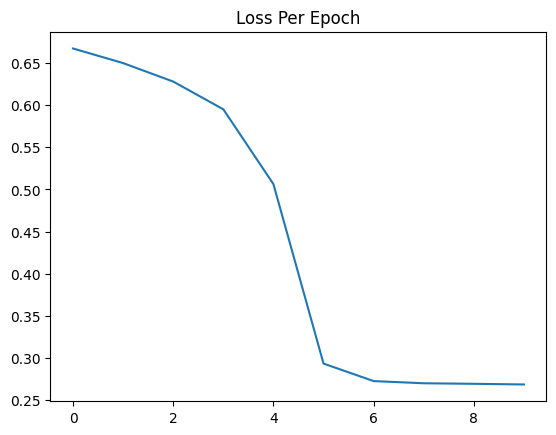

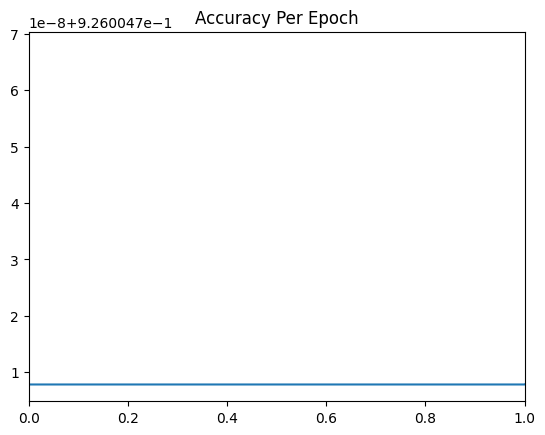

In [17]:
loss = hist.history['loss']

plt.plot(range(len(loss)), loss)
plt.title("Loss Per Epoch")
plt.show()

acc = hist.history['accuracy']
plt.plot(range(len(acc)), acc)
plt.title("Accuracy Per Epoch")
plt.xlim(0, 1)
plt.show()

(256, 256, 2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


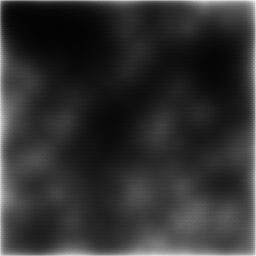

In [39]:
index = random.randint(0, dataset_in.shape[0])

example = dataset_in[index]
print(example.shape)
example = np.reshape(example, (1, 256, 256, 2))

out_example = model2.predict(example)
out_example = np.reshape(out_example, (256, 256, 1))

out_example = out_example * 255 / np.max(out_example)

cv2_imshow(out_example)